# Item and Category Exploratory Data Analysis

**Project:** Behavior-Aware Sequential Recommendation for Next Purchase Prediction

## Objective

This notebook explores item popularity, product category distributions, and category-level shopping behaviors in the Synerise RecSys 2025 dataset. The broader project investigates whether incorporating shopping cart activity improves next-purchase recommendations compared with using purchase history alone, and whether the usefulness of cart behavior varies across product categories.

This analysis focuses on three objectives:

1. **Item Popularity:** Examine the long-tail distribution of product purchases and quantify how purchase activity is concentrated among popular items.
2. **Category Distribution:** Investigate how products, purchases, cart additions, and cart removals are distributed across anonymized product categories.
3. **Category Behavioral Differences:** Compare category-level cart interaction patterns and use exploratory clustering to investigate whether categories exhibit distinct behavioral characteristics.

## Dataset

The analysis uses the Synerise RecSys 2025 dataset, containing anonymized retail interactions from June through December 2022. We use purchase, add-to-cart, and remove-from-cart events alongside product properties containing anonymized category identifiers.

Following the team's preprocessing pipeline, the analysis is restricted to an **active-user cohort of 520,417 users**, defined as users with at least five total events across purchases, cart additions, and cart removals.

This cohort retains approximately 70% of the original event volume but represents more active shoppers. Therefore, findings may not generalize to the full customer population.

The analysis is exploratory and intended to inform subsequent recommendation modeling rather than establish predictive improvements.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering and evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

/Users/sonikapuvvada/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/sonikapuvvada/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
# High-resolution plots in JupyterLab
from IPython.display import set_matplotlib_formats
set_matplotlib_formats("retina")

# Consistent visualization style
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1
)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.titlesize": 16,
    "axes.titleweight": "semibold",
    "axes.labelsize": 13,
    "axes.labelweight": "medium",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.2
})

/var/folders/0f/cz_b2mds3193580080w07hd00000gn/T/ipykernel_30582/3756640596.py:3: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats("retina")


In [3]:
# Load the subsampled event datasets
purchases = pd.read_parquet("data/product_buy_subsampled.parquet")
cart_adds = pd.read_parquet("data/add_to_cart_subsampled.parquet")
cart_removes = pd.read_parquet("data/remove_from_cart_subsampled.parquet")

# Load product information
products = pd.read_parquet("data/product_properties.parquet")

## Data Preparation and Validation

### Data Loading and Validation

We load the three subsampled interaction datasets (`product_buy`, `add_to_cart`, and `remove_from_cart`) alongside the product properties dataset.

Each interaction record contains a customer identifier (`client_id`), timestamp, and product identifier (`sku`). The product properties dataset provides category identifiers and additional product attributes.

Before performing exploratory analysis, we inspect dataset dimensions and data types, verify SKU uniqueness in the product properties table, and check whether interaction records can be matched to product information.

All three interaction datasets achieved **100% SKU coverage**, and the product properties table contained no duplicate SKU identifiers. Consequently, event records can be joined with product categories without losing observations or introducing duplicate rows through the join.

In [4]:
datasets = {
    "Purchases": purchases,
    "Cart additions": cart_adds,
    "Cart removals": cart_removes,
    "Product properties": products
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(df.dtypes)


Purchases
Shape: (1171501, 3)
Columns: ['client_id', 'timestamp', 'sku']
client_id             int64
timestamp    datetime64[ns]
sku                   int64
dtype: object

Cart additions
Shape: (4890231, 3)
Columns: ['client_id', 'timestamp', 'sku']
client_id             int64
timestamp    datetime64[ns]
sku                   int64
dtype: object

Cart removals
Shape: (2229315, 3)
Columns: ['client_id', 'timestamp', 'sku']
client_id             int64
timestamp    datetime64[ns]
sku                   int64
dtype: object

Product properties
Shape: (1534050, 4)
Columns: ['sku', 'category', 'price', 'name']
sku          int64
category     int64
price        int64
name        object
dtype: object


### Data Quality and SKU Coverage

In [5]:
print("Unique SKUs in purchases:", purchases["sku"].nunique())
print("Unique SKUs in cart additions:", cart_adds["sku"].nunique())
print("Unique SKUs in cart removals:", cart_removes["sku"].nunique())
print("Unique SKUs in product properties:", products["sku"].nunique())

print("\nDuplicate SKU rows in product properties:",
      products["sku"].duplicated().sum())

Unique SKUs in purchases: 449958
Unique SKUs in cart additions: 1069877
Unique SKUs in cart removals: 741269
Unique SKUs in product properties: 1534050

Duplicate SKU rows in product properties: 0


In [6]:
product_skus = pd.Index(products["sku"].unique())

for name, df in [
    ("Purchases", purchases),
    ("Cart additions", cart_adds),
    ("Cart removals", cart_removes)
]:
    matched = df["sku"].isin(product_skus)

    print(f"\n{name}")
    print(f"Matched events: {matched.sum():,}")
    print(f"Unmatched events: {(~matched).sum():,}")
    print(f"SKU coverage by event: {matched.mean():.2%}")


Purchases
Matched events: 1,171,501
Unmatched events: 0
SKU coverage by event: 100.00%

Cart additions
Matched events: 4,890,231
Unmatched events: 0
SKU coverage by event: 100.00%

Cart removals
Matched events: 2,229,315
Unmatched events: 0
SKU coverage by event: 100.00%


## 1. Item Popularity Analysis

We examine how purchase activity is distributed across products
to determine whether a small number of popular items account
for a large proportion of purchases.

In [7]:
# Count how many times each product was purchased
item_popularity = purchases["sku"].value_counts()

print("Number of purchased products:", len(item_popularity))
print("\nPurchase count statistics:")
print(item_popularity.describe())

Number of purchased products: 449958

Purchase count statistics:
count    449958.000000
mean          2.603579
std           9.099799
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        1509.000000
Name: count, dtype: float64


In [8]:
print("Top 10 most purchased products:")
print(item_popularity.head(10))

Top 10 most purchased products:
sku
219232     1509
52586      1104
1243077     997
561077      930
1202337     808
301108      741
1492640     738
234831      718
724841      678
940412      565
Name: count, dtype: int64


In [9]:
# Count products with exactly one purchase
single_purchase_items = (item_popularity == 1).sum()

# Calculate their percentage among purchased products
single_purchase_pct = single_purchase_items / len(item_popularity) * 100

print(f"Products purchased exactly once: {single_purchase_items:,}")
print(f"Percentage of purchased products: {single_purchase_pct:.2f}%")

Products purchased exactly once: 297,182
Percentage of purchased products: 66.05%


In [10]:
# Total number of purchase events
total_purchases = item_popularity.sum()

# Calculate purchase share for the most popular products
for pct in [1, 5, 10]:
    n_items = int(np.ceil(len(item_popularity) * pct / 100))

    top_purchases = item_popularity.head(n_items).sum()

    purchase_share = top_purchases / total_purchases * 100

    print(f"Top {pct}% of products account for "
          f"{purchase_share:.2f}% of purchases")

Top 1% of products account for 22.83% of purchases
Top 5% of products account for 41.81% of purchases
Top 10% of products account for 52.08% of purchases


### Distribution of Item Popularity

We visualize the distribution of purchase counts across products
to investigate the long-tail pattern in item popularity.

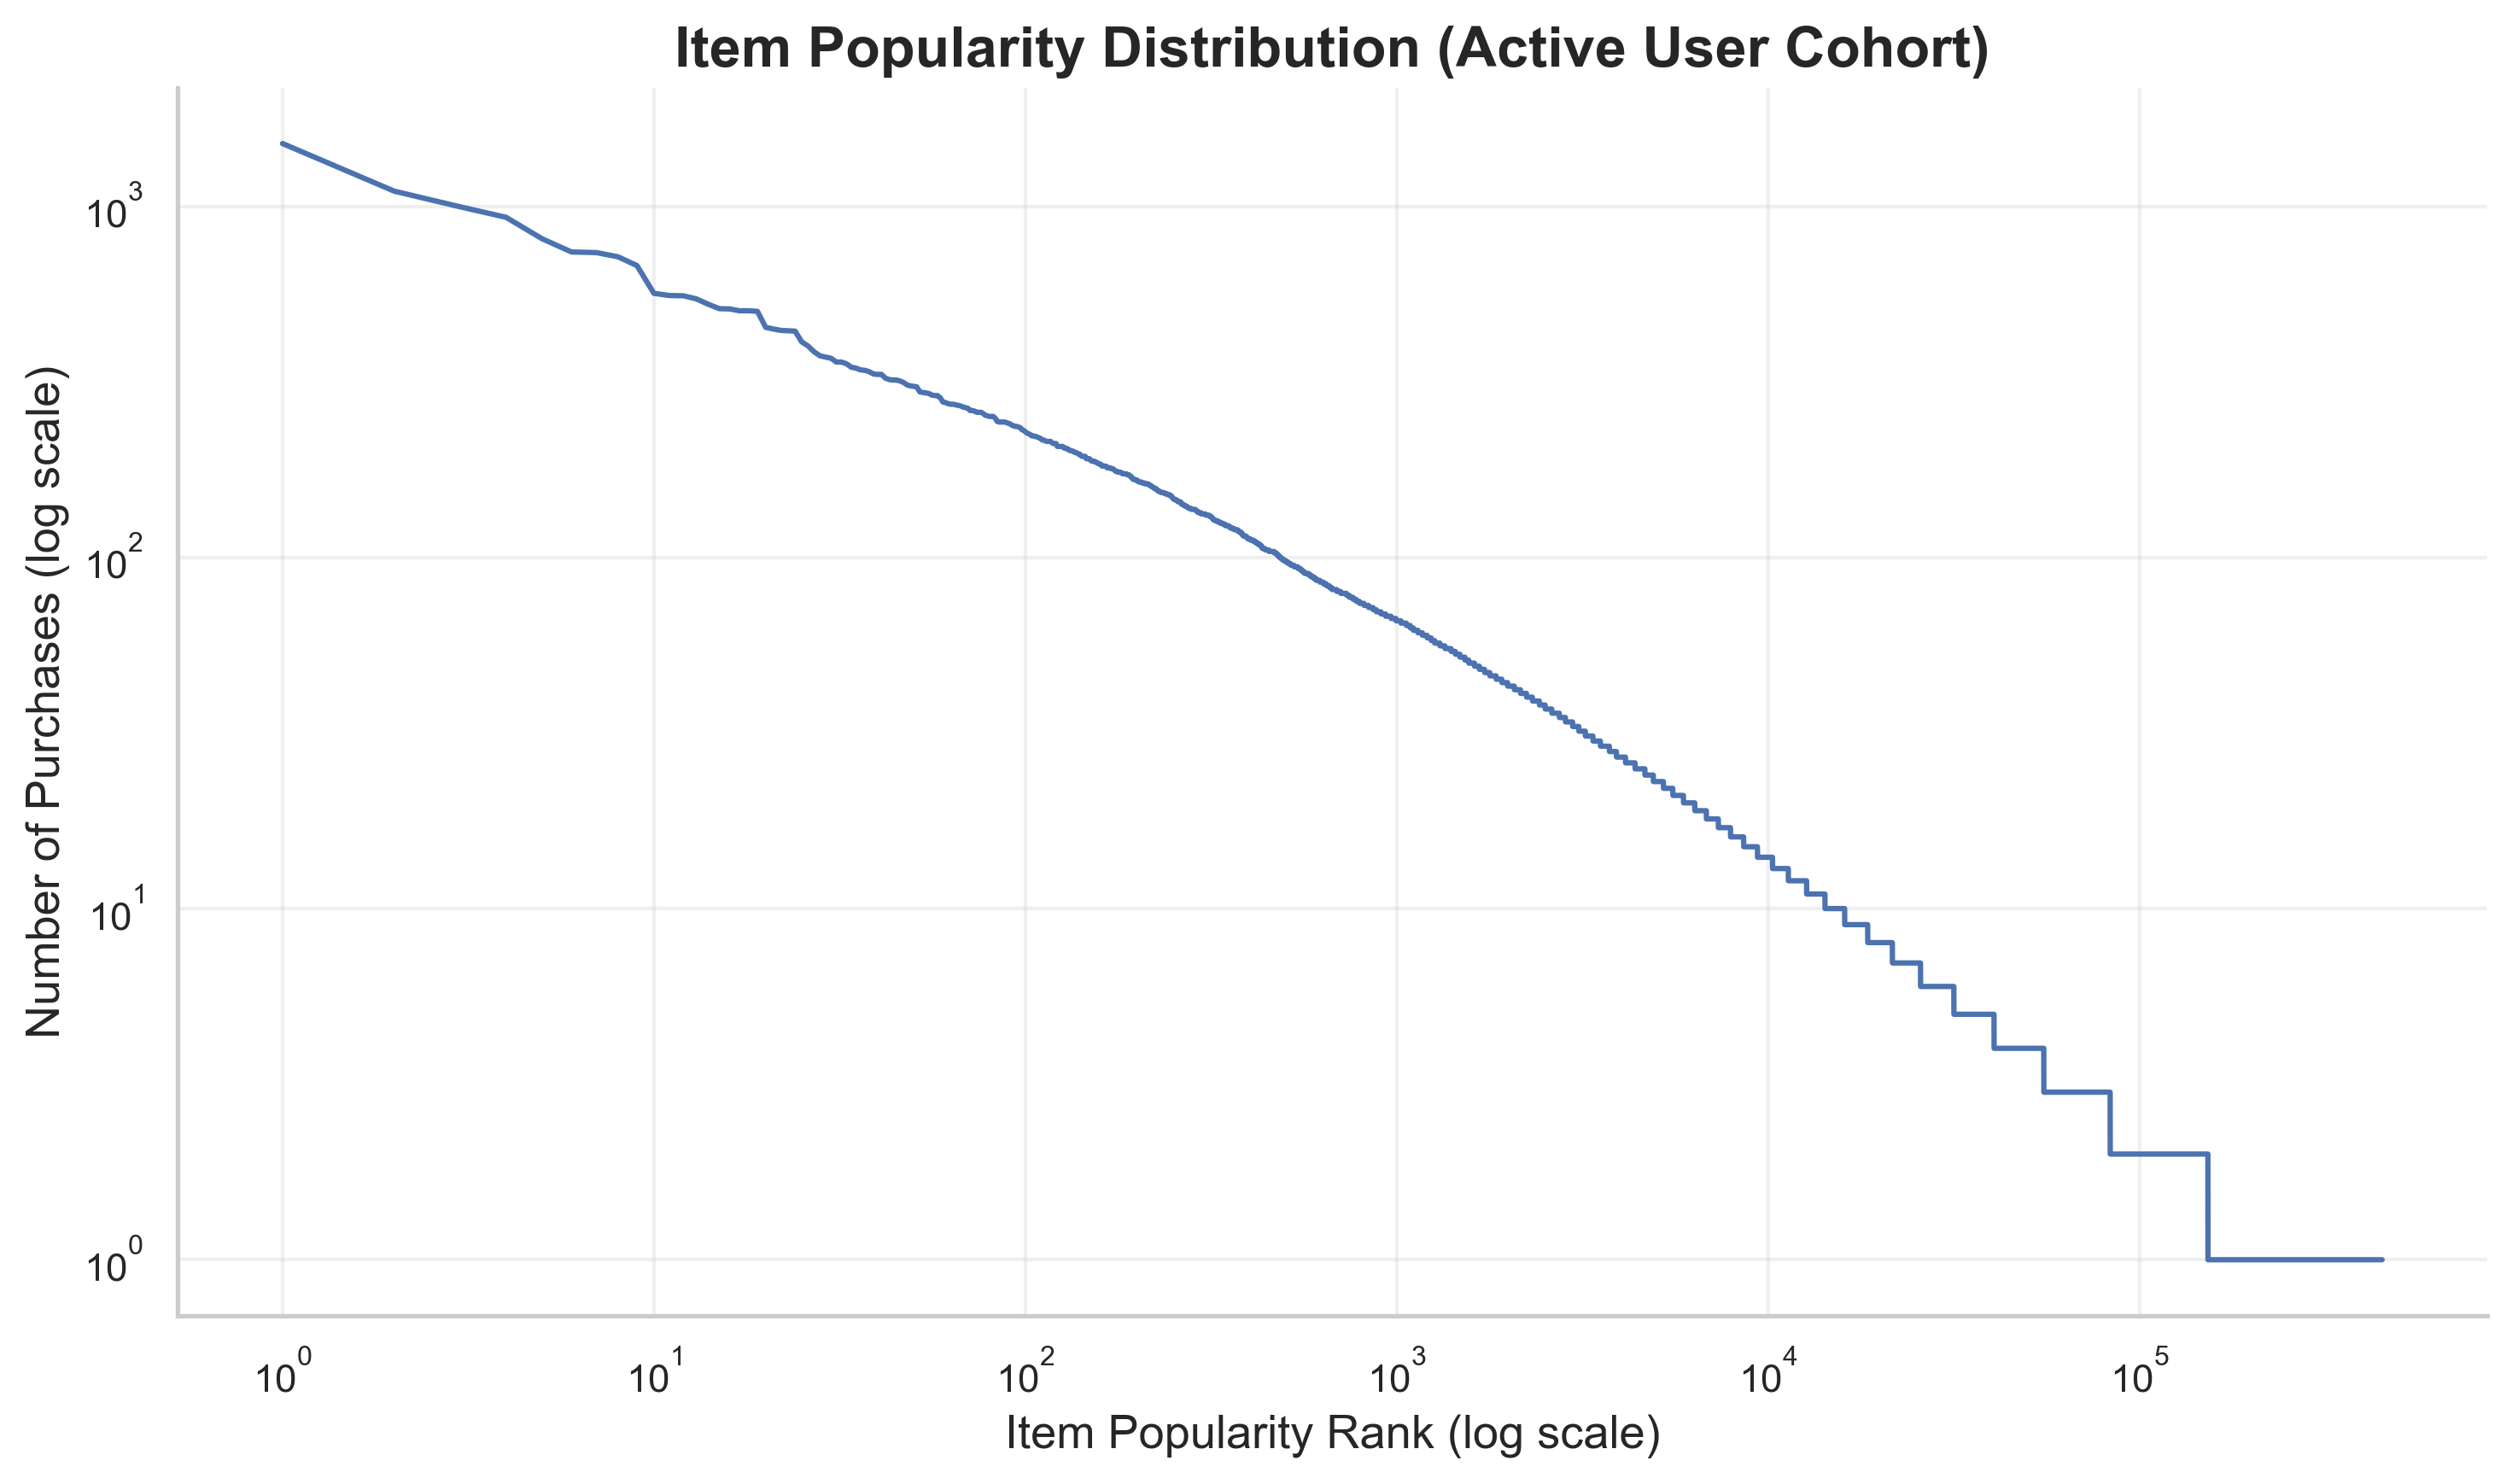

In [11]:
# Assign popularity ranks
ranks = np.arange(1, len(item_popularity) + 1)

plt.figure(figsize=(10, 6))

plt.plot(ranks, item_popularity.values)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Item Popularity Rank (log scale)")
plt.ylabel("Number of Purchases (log scale)")
plt.title("Item Popularity Distribution (Active User Cohort)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    "figures/item_popularity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Key Findings

The active-user cohort contains **449,958 unique purchased products** across **1,171,501 purchase events**. Item popularity is highly right-skewed, with a mean of 2.60 purchases per product but a median of only 1. In particular, **66.05% of purchased products (297,182 SKUs) were purchased exactly once**, while the most frequently purchased product appeared in 1,509 purchase events.

Purchase activity is concentrated among a relatively small subset of products. The **top 1% of purchased products account for 22.83% of purchases**, while the top 5% and 10% account for 41.81% and 52.08%, respectively. The rank-popularity plot further illustrates this long-tail distribution, with a small number of highly popular products and a large proportion of infrequently purchased products.

These findings highlight the importance of evaluating a popularity-based recommendation baseline and suggest potential challenges in learning reliable item representations from sparse purchase histories. They also provide context for the project's proposed candidate item pool of frequently purchased SKUs. All findings are based on the selected active-user cohort and may not generalize to the full customer population.

## 2. Category Distribution Analysis

We examine the distribution of products and shopping activity across
anonymized product categories. This analysis helps identify category
imbalances and provides context for investigating whether shopping
behavior differs across categories.

In [12]:
# Count the number of unique categories
n_categories = products["category"].nunique()

# Count the number of products in each category
category_sizes = products["category"].value_counts()

print(f"Number of unique categories: {n_categories:,}")

print("\nProducts per category statistics:")
print(category_sizes.describe())

print("\nTop 10 categories by number of products:")
print(category_sizes.head(10))

Number of unique categories: 6,912

Products per category statistics:
count     6912.000000
mean       221.940104
std        891.366201
min          1.000000
25%          8.000000
50%         42.000000
75%        164.000000
max      52009.000000
Name: count, dtype: float64

Top 10 categories by number of products:
category
258     52009
949     13748
1096    12799
1135    10677
2890     8506
2964     8442
2698     8374
2155     7579
384      7562
1429     7524
Name: count, dtype: int64


In [13]:
# Join purchase events with product category information
purchases_cat = purchases.merge(
    products[["sku", "category"]],
    on="sku",
    how="left",
    validate="many_to_one"
)

print("Original purchase events:", len(purchases))
print("Purchase events after joining:", len(purchases_cat))

print("\nMissing category values:",
      purchases_cat["category"].isna().sum())

purchases_cat.head()

Original purchase events: 1171501
Purchase events after joining: 1171501

Missing category values: 0


,client_id,timestamp,sku,category
0,10551361,2022-09-22 06:28:20,728970,6118
1,10551361,2022-09-30 18:23:25,1117918,6118
2,10551361,2022-10-15 20:21:10,655683,1667
3,10522335,2022-08-06 11:31:20,19966,2040
4,10522335,2022-09-29 11:22:45,182770,6302


In [14]:
# Count purchase events for each category
category_purchases = purchases_cat["category"].value_counts()

print("Number of categories with purchases:",
      len(category_purchases))

print("\nPurchases per category statistics:")
print(category_purchases.describe())

print("\nTop 10 categories by purchase events:")
print(category_purchases.head(10))

Number of categories with purchases: 5917

Purchases per category statistics:
count     5917.000000
mean       197.989015
std        786.505115
min          1.000000
25%          6.000000
50%         28.000000
75%        123.000000
max      25426.000000
Name: count, dtype: float64

Top 10 categories by purchase events:
category
1966    25426
258     23686
1096    22440
4092    11066
2964    10100
1135     9582
3398     8398
791      8258
3138     8167
6356     7379
Name: count, dtype: int64


In [15]:
# Combine product counts and purchase counts by category
category_comparison = pd.DataFrame({
    "product_count": category_sizes,
    "purchase_count": category_purchases
})

# Include categories without purchases
category_comparison["purchase_count"] = (
    category_comparison["purchase_count"].fillna(0).astype(int)
)

print(category_comparison.head())

print("\nNumber of categories:", len(category_comparison))

          product_count  purchase_count
category                               
0                   230             124
1                   957             678
2                    24               6
3                    41              20
4                    64              49

Number of categories: 6912


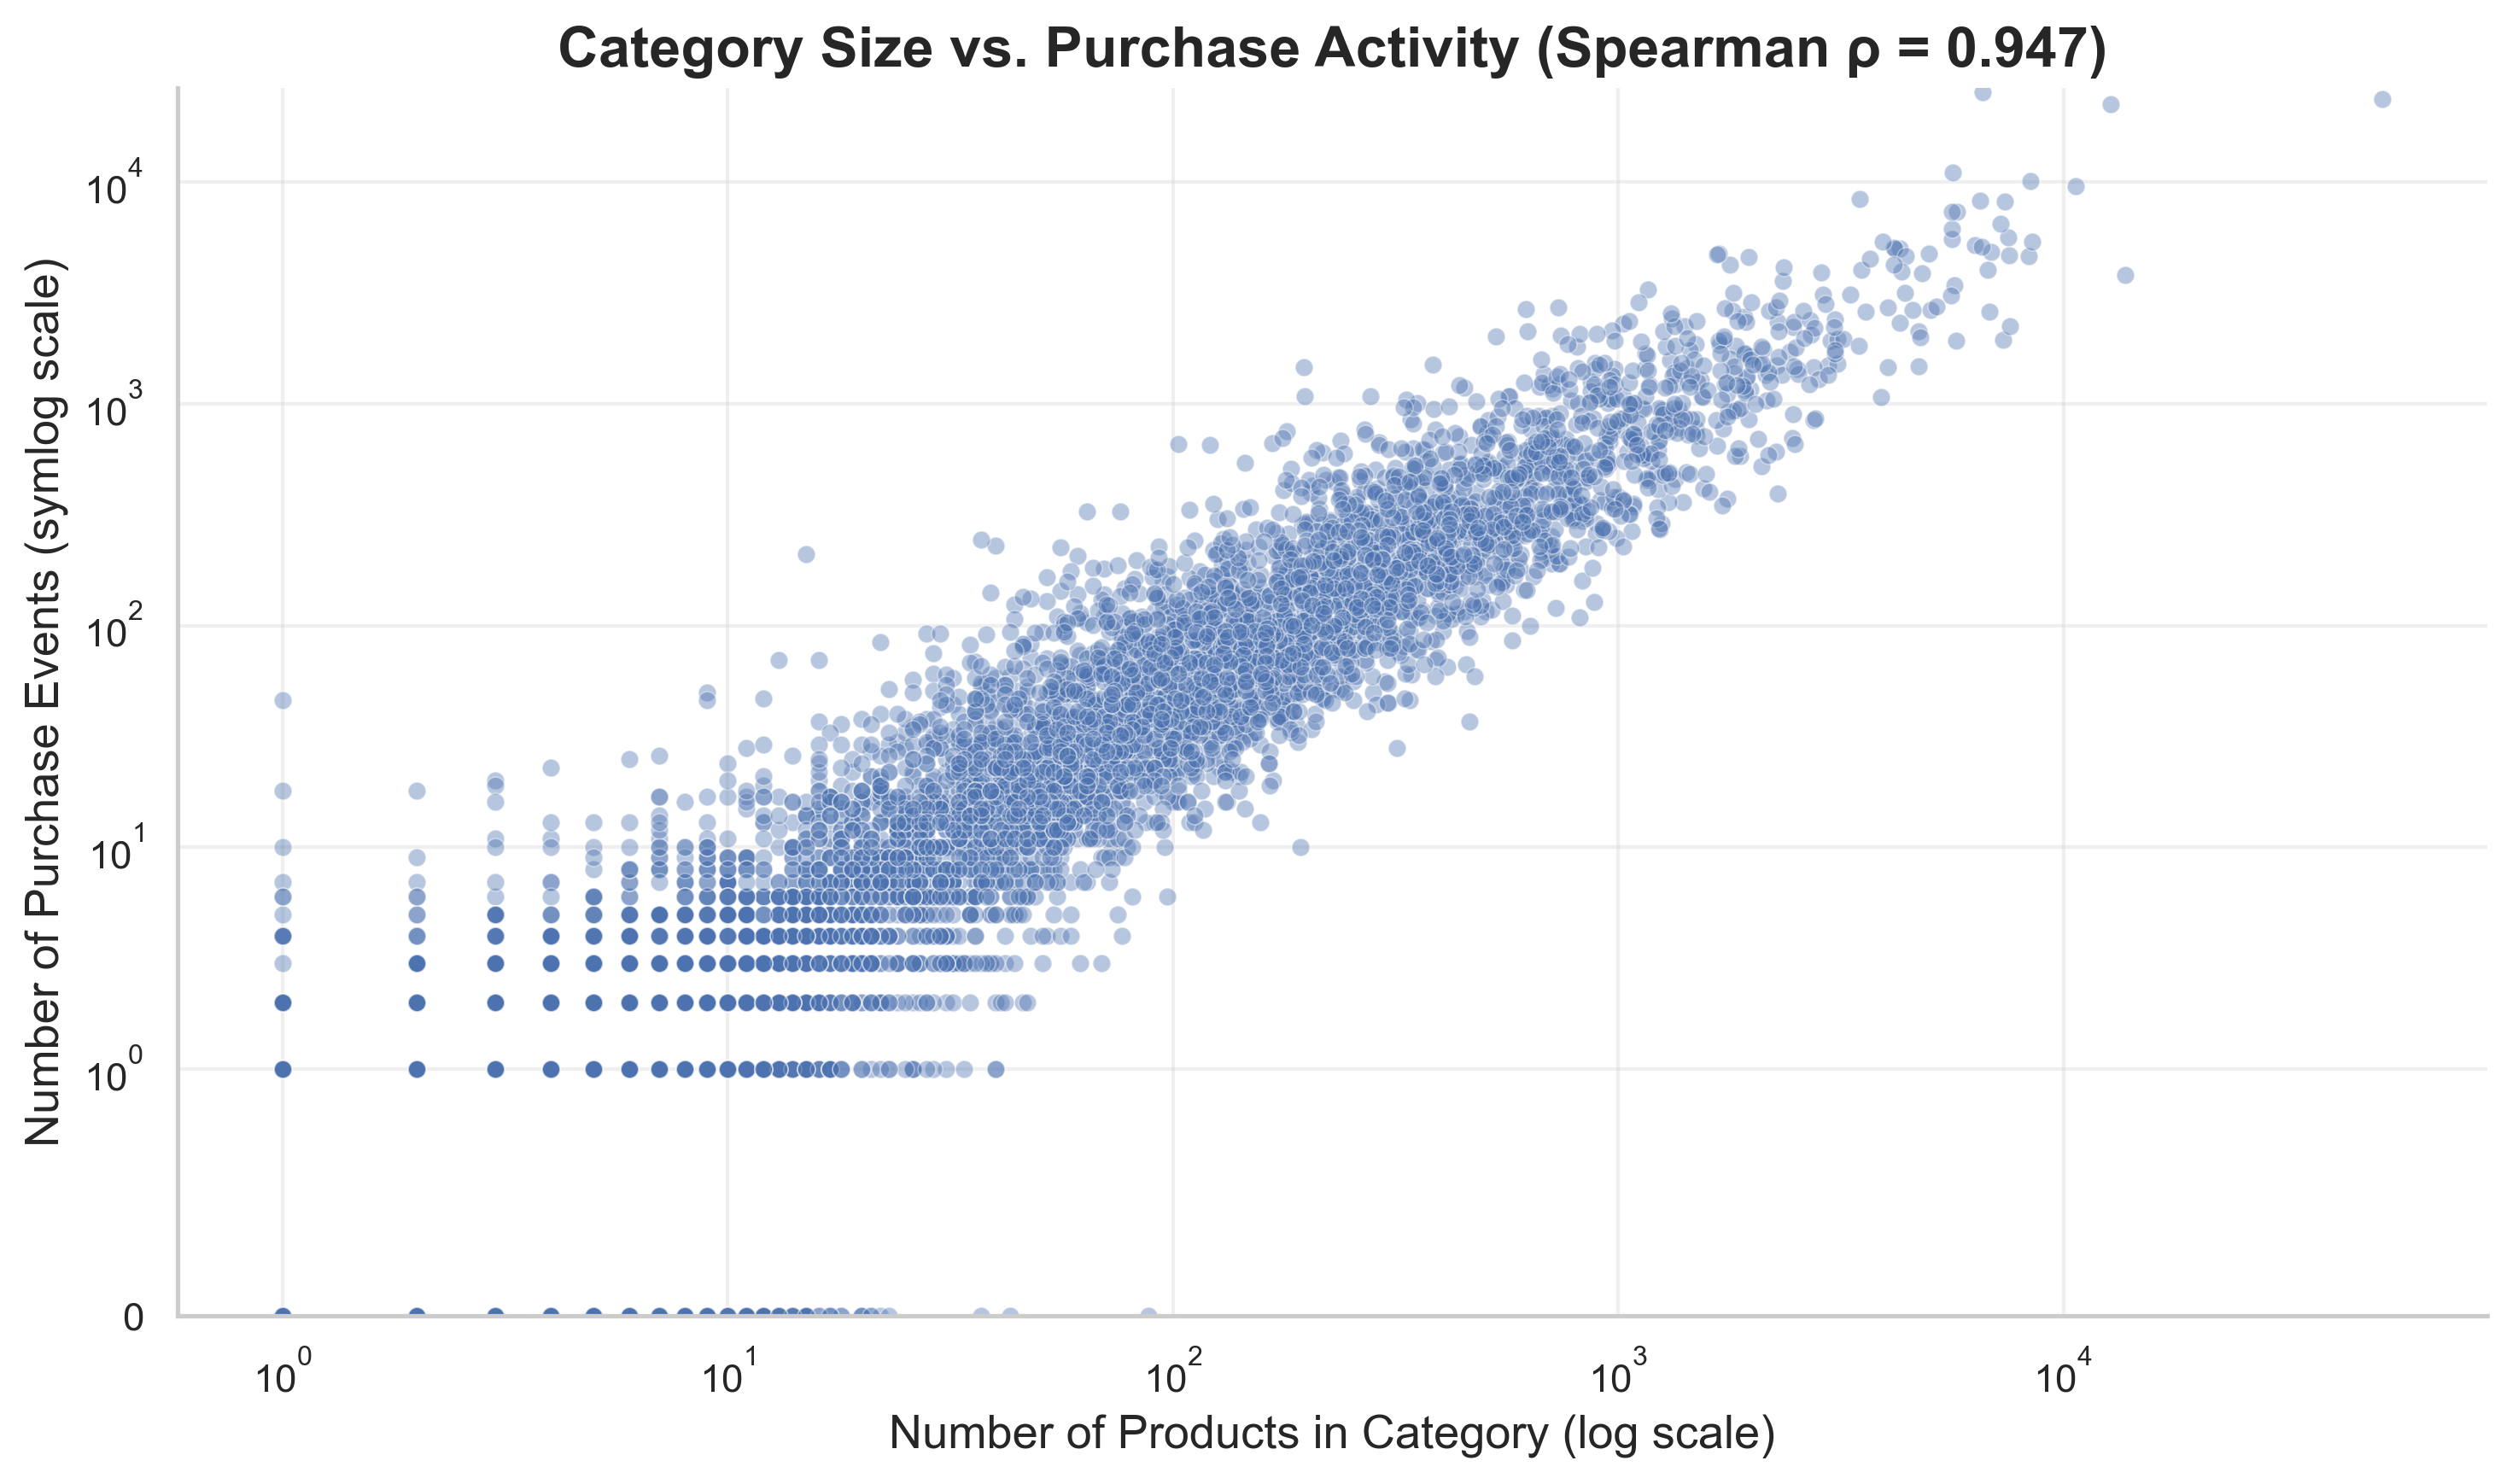

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=category_comparison,
    x="product_count",
    y="purchase_count",
    alpha=0.4,
    s=25
)

plt.xscale("log")
plt.yscale("symlog", linthresh=1)
plt.ylim(bottom=0)

plt.xlabel("Number of Products in Category (log scale)")
plt.ylabel("Number of Purchase Events (symlog scale)")
plt.title("Category Size vs. Purchase Activity (Spearman ρ = 0.947)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    "figures/category_size_vs_purchases.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [17]:
# Spearman correlation between category size and purchase activity
correlation = category_comparison[
    ["product_count", "purchase_count"]
].corr(method="spearman")

print(correlation)

                product_count  purchase_count
product_count        1.000000        0.946928
purchase_count       0.946928        1.000000


In [18]:
# Calculate purchase activity relative to category size
category_comparison["purchases_per_product"] = (
    category_comparison["purchase_count"] /
    category_comparison["product_count"]
)

print("Purchases per product statistics:")
print(category_comparison["purchases_per_product"].describe())

# Examine categories with at least 100 products
large_categories = category_comparison[
    category_comparison["product_count"] >= 100
]

print("\nTop 10 categories by purchases per product (100+ products):")
print(
    large_categories.sort_values(
        "purchases_per_product",
        ascending=False
    ).head(10)
)

Purchases per product statistics:
count    6912.000000
mean        0.552256
std         0.862011
min         0.000000
25%         0.200000
50%         0.400000
75%         0.705882
max        46.000000
Name: purchases_per_product, dtype: float64

Top 10 categories by purchases per product (100+ products):
          product_count  purchase_count  purchases_per_product
category                                                      
6207                197            1467               7.446701
2492                103             658               6.388350
6605                198            1085               5.479798
6794                121             653               5.396694
3207                621            2676               4.309179
613                 180             756               4.200000
5397                176             703               3.994318
1252                167             666               3.988024
1876                384            1503               3.914062


In [19]:
# Join product category information to cart additions
cart_adds_cat = cart_adds.merge(
    products[["sku", "category"]],
    on="sku",
    how="left",
    validate="many_to_one"
)

# Join product category information to cart removals
cart_removes_cat = cart_removes.merge(
    products[["sku", "category"]],
    on="sku",
    how="left",
    validate="many_to_one"
)

# Verify the joins
print("Cart additions:")
print("Original events:", len(cart_adds))
print("Events after join:", len(cart_adds_cat))
print("Missing categories:", cart_adds_cat["category"].isna().sum())

print("\nCart removals:")
print("Original events:", len(cart_removes))
print("Events after join:", len(cart_removes_cat))
print("Missing categories:", cart_removes_cat["category"].isna().sum())

Cart additions:
Original events: 4890231
Events after join: 4890231
Missing categories: 0

Cart removals:
Original events: 2229315
Events after join: 2229315
Missing categories: 0


In [20]:
# Count cart additions and removals by category
category_cart_adds = cart_adds_cat["category"].value_counts()
category_cart_removes = cart_removes_cat["category"].value_counts()

print("Categories with cart additions:", len(category_cart_adds))
print("Categories with cart removals:", len(category_cart_removes))

print("\nCart additions per category statistics:")
print(category_cart_adds.describe())

print("\nCart removals per category statistics:")
print(category_cart_removes.describe())

print("\nTop 10 categories by cart additions:")
print(category_cart_adds.head(10))

print("\nTop 10 categories by cart removals:")
print(category_cart_removes.head(10))

Categories with cart additions: 6549
Categories with cart removals: 6268

Cart additions per category statistics:
count      6549.000000
mean        746.714155
std        3337.820839
min           1.000000
25%          13.000000
50%          78.000000
75%         404.000000
max      124226.000000
Name: count, dtype: float64

Cart removals per category statistics:
count     6268.000000
mean       355.666082
std       1560.891934
min          1.000000
25%          7.000000
50%         40.000000
75%        198.000000
max      49216.000000
Name: count, dtype: float64

Top 10 categories by cart additions:
category
1966    124226
258      97419
1096     67314
791      60827
3138     57615
6356     47591
1135     43413
4092     43401
3398     36402
6347     36089
Name: count, dtype: int64

Top 10 categories by cart removals:
category
1966    49216
258     45521
791     32315
3138    31747
1096    26892
6356    25928
4092    20865
1135    19795
6347    17149
2663    17028
Name: count, dtype: i

In [21]:
# Combine product counts and event counts by category
category_summary = category_comparison.copy()

category_summary["cart_add_count"] = category_cart_adds
category_summary["cart_remove_count"] = category_cart_removes

# Categories without certain events receive a count of zero
category_summary[["cart_add_count", "cart_remove_count"]] = (
    category_summary[["cart_add_count", "cart_remove_count"]]
    .fillna(0)
    .astype(int)
)

print(category_summary.head(10))

          product_count  purchase_count  purchases_per_product  \
category                                                         
0                   230             124               0.539130   
1                   957             678               0.708464   
2                    24               6               0.250000   
3                    41              20               0.487805   
4                    64              49               0.765625   
5                   288             233               0.809028   
6                   367             193               0.525886   
7                    10               2               0.200000   
8                     1               0               0.000000   
9                    11              15               1.363636   

          cart_add_count  cart_remove_count  
category                                     
0                    549                285  
1                   2820               1036  
2                     2

### Category-Level Shopping Activity

We compare purchase, add-to-cart, and remove-from-cart event counts
across the most frequently purchased categories to examine how
shopping activity is distributed across event types.

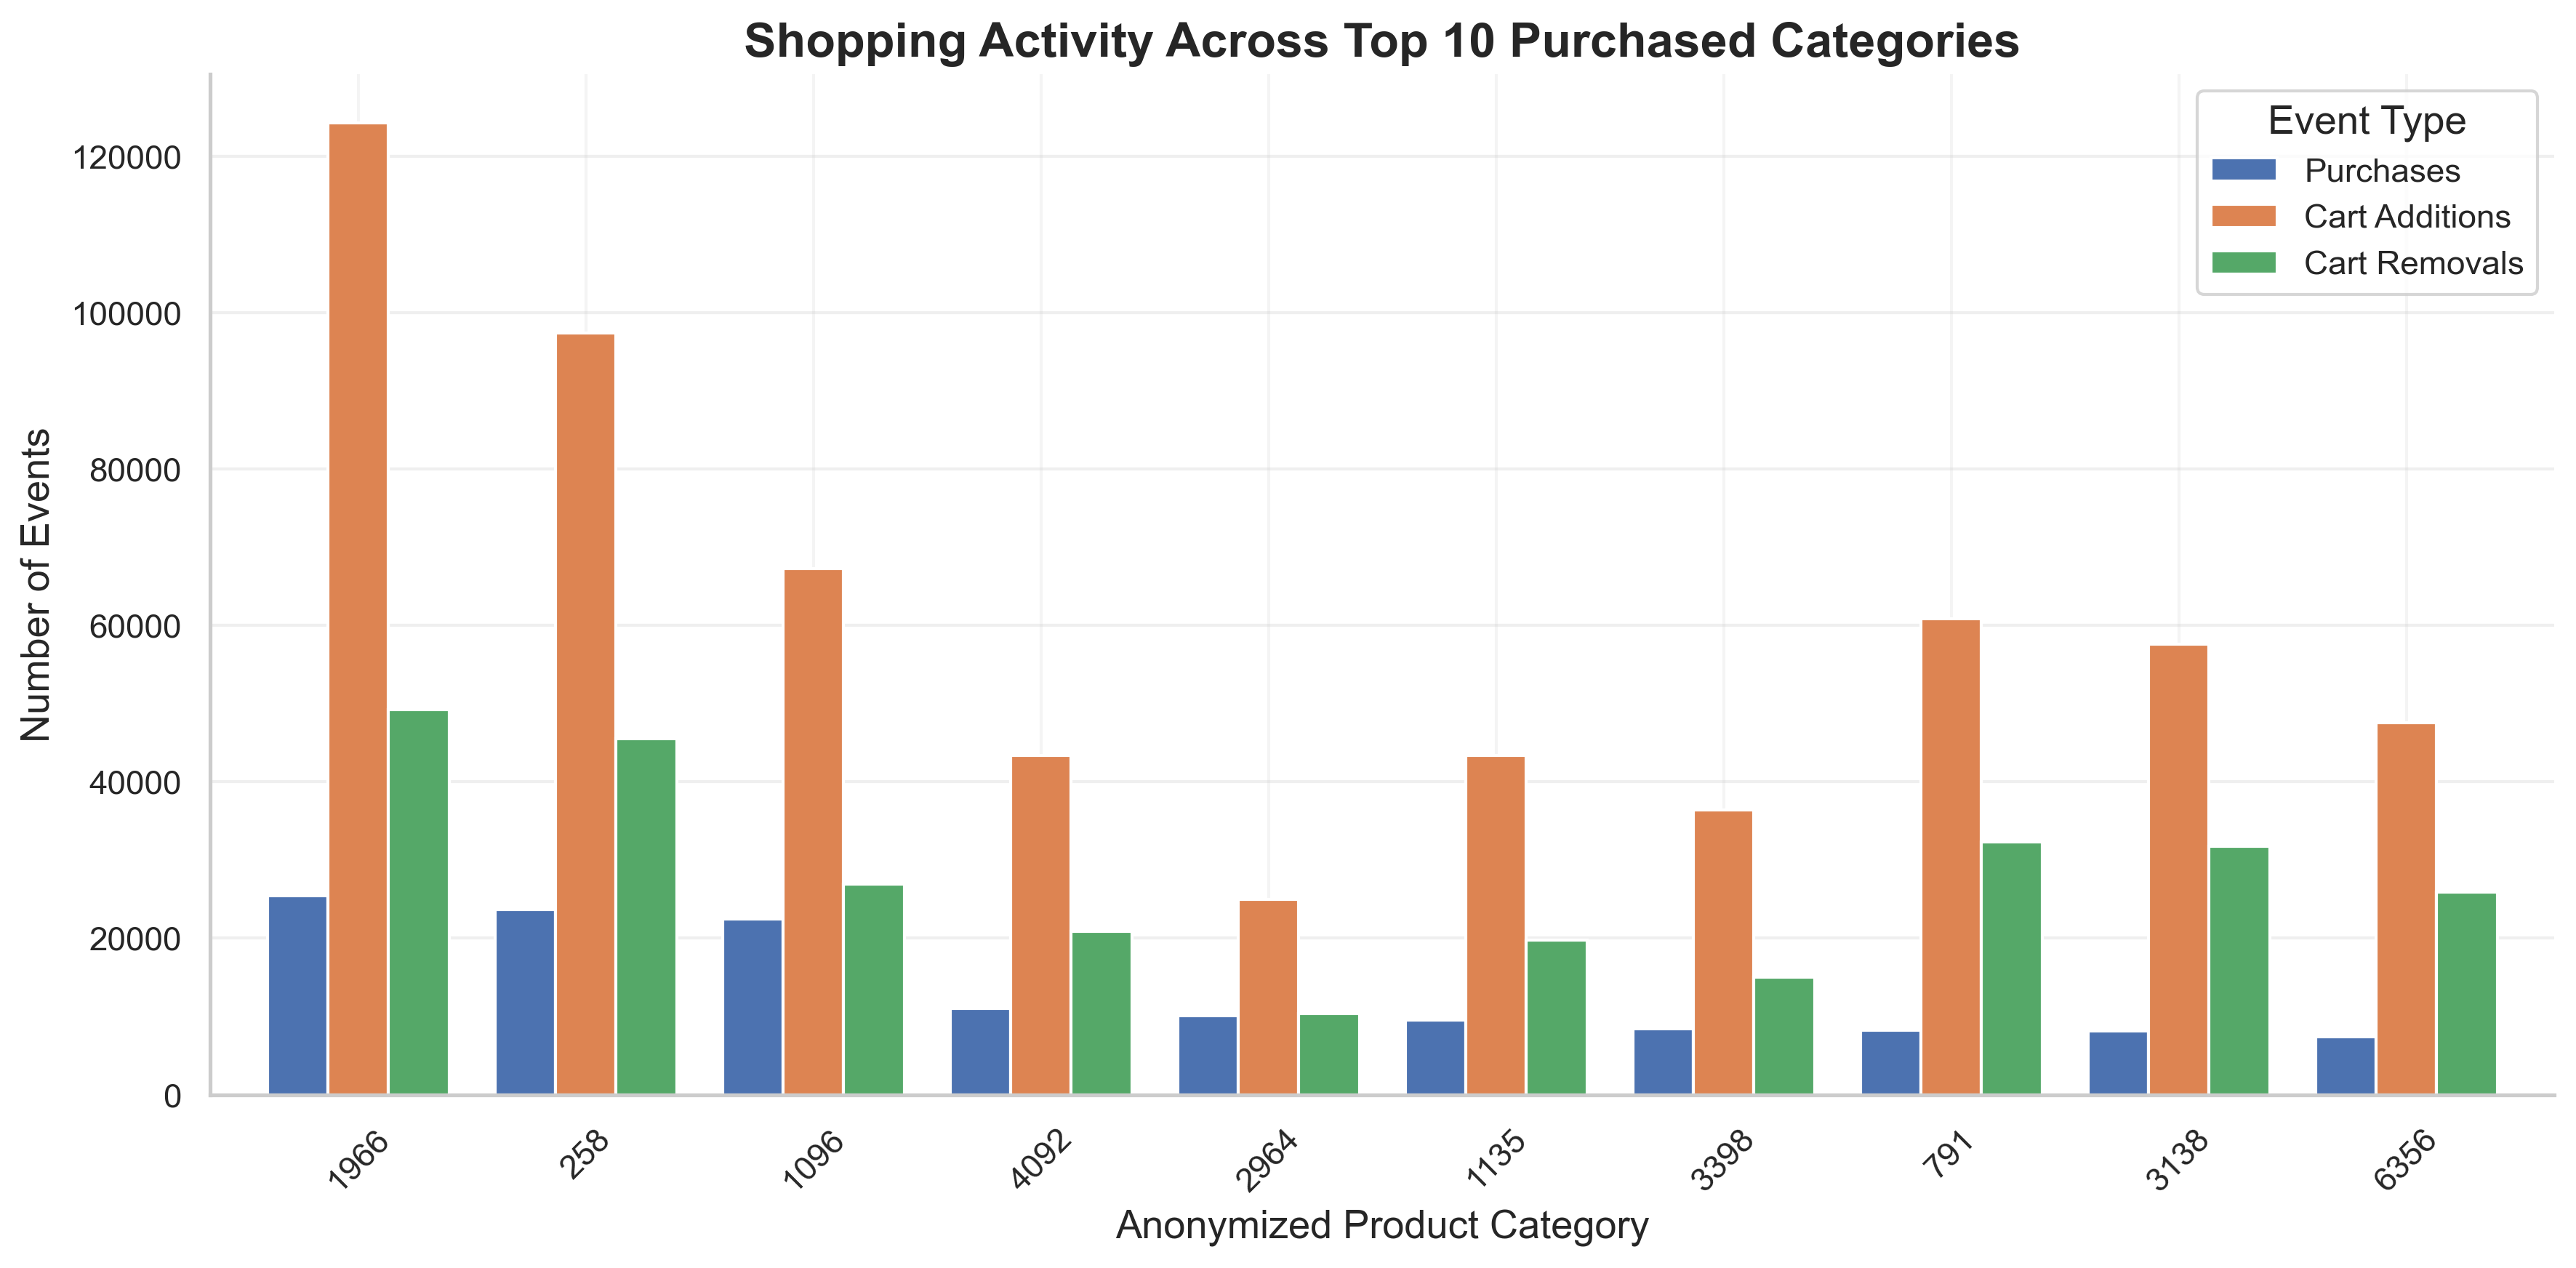

In [22]:
# Select the 10 categories with the most purchases
top_categories = category_summary.nlargest(
    10, "purchase_count"
)

# Select event count columns
event_counts = top_categories[
    ["purchase_count", "cart_add_count", "cart_remove_count"]
].copy()

# Rename columns for readability
event_counts.columns = [
    "Purchases",
    "Cart Additions",
    "Cart Removals"
]

# Treat category IDs as labels
event_counts.index = event_counts.index.astype(str)

# Create grouped bar chart
ax = event_counts.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.xlabel("Anonymized Product Category")
plt.ylabel("Number of Events")
plt.title("Shopping Activity Across Top 10 Purchased Categories")
plt.xticks(rotation=45)
plt.legend(title="Event Type")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "figures/category_event_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Key Findings

The product catalog contains **6,912 anonymized categories**, with a highly uneven distribution of products across categories. The median category contains 42 products, compared with a mean of 221.94, and the largest category contains 52,009 products.

Of these categories, **5,917 have recorded purchases**, **6,549 have cart additions**, and **6,268 have cart removals** in the active-user cohort. Purchase activity is highly concentrated, with a median of 28 purchases per category compared with a mean of 197.99. Cart activity covers a broader range of categories than purchases, providing additional observations of customer interactions.

Category size and purchase activity exhibit a strong positive association (**Spearman correlation = 0.947**), indicating that categories with more products generally receive more purchases. However, purchase activity relative to category size varies considerably, with a median of 0.40 purchases per catalog product and substantially higher values in some categories.

The grouped bar chart shows that cart additions substantially exceed purchases across the 10 most frequently purchased categories. The relative frequency of cart additions and removals also differs between categories, suggesting potentially distinct shopping behavior patterns.

These findings motivate further investigation of **category-level behavioral differences** and provide context for evaluating whether category-conditioned recommendation models offer advantages over global models. However, descriptive event counts alone cannot establish whether cart behavior improves next-purchase prediction.

## 3. Category Behavioral Differences

We investigate whether anonymized product categories exhibit
different shopping behavior patterns by comparing normalized
purchase, cart-addition, and cart-removal activity.

These comparisons help assess whether category-specific behavioral
patterns exist that may motivate category-conditioned recommendation
models.

In [23]:
# Calculate cart additions per purchase
category_summary["adds_per_purchase"] = (
    category_summary["cart_add_count"] /
    category_summary["purchase_count"].replace(0, np.nan)
)

# Calculate cart removals per cart addition
category_summary["removes_per_add"] = (
    category_summary["cart_remove_count"] /
    category_summary["cart_add_count"].replace(0, np.nan)
)

# Summarize behavioral ratios
print("Cart additions per purchase:")
print(category_summary["adds_per_purchase"].describe())

print("\nCart removals per addition:")
print(category_summary["removes_per_add"].describe())

Cart additions per purchase:
count    5917.000000
mean        4.178264
std         2.592612
min         0.000000
25%         3.000000
50%         3.761538
75%         4.695652
max        74.000000
Name: adds_per_purchase, dtype: float64

Cart removals per addition:
count    6549.000000
mean        0.464675
std         0.307972
min         0.000000
25%         0.379310
50%         0.445748
75%         0.512605
max        14.000000
Name: removes_per_add, dtype: float64


In [24]:
# Compare minimum activity thresholds for category analysis
thresholds = [10, 30, 50, 100]

for threshold in thresholds:
    eligible = category_summary[
        (category_summary["purchase_count"] >= threshold) &
        (category_summary["cart_add_count"] >= threshold)
    ]

    print(f"\nMinimum {threshold} purchases and {threshold} cart additions")
    print(f"Categories retained: {len(eligible):,}")
    print(f"Percentage of all categories: {len(eligible) / len(category_summary) * 100:.2f}%")
    print(f"Purchase events retained: {eligible['purchase_count'].sum() / category_summary['purchase_count'].sum() * 100:.2f}%")
    print(f"Cart-add events retained: {eligible['cart_add_count'].sum() / category_summary['cart_add_count'].sum() * 100:.2f}%")


Minimum 10 purchases and 10 cart additions
Categories retained: 3,988
Percentage of all categories: 57.70%
Purchase events retained: 99.40%
Cart-add events retained: 99.34%

Minimum 30 purchases and 30 cart additions
Categories retained: 2,901
Percentage of all categories: 41.97%
Purchase events retained: 97.72%
Cart-add events retained: 97.74%

Minimum 50 purchases and 50 cart additions
Categories retained: 2,376
Percentage of all categories: 34.38%
Purchase events retained: 95.99%
Cart-add events retained: 96.12%

Minimum 100 purchases and 100 cart additions
Categories retained: 1,679
Percentage of all categories: 24.29%
Purchase events retained: 91.76%
Cart-add events retained: 92.03%


### Filtering Categories for Behavioral Analysis

To reduce the influence of categories with sparse interaction
histories, we restrict the initial behavioral analysis to
categories with at least 50 purchase events and 50 cart-addition
events.

This retains 2,376 categories (34.38% of all categories), while
preserving 95.99% of purchase events and 96.12% of cart additions.

The threshold is an exploratory choice intended to balance
category representation with sufficient observed activity.

In [25]:
# Keep categories with sufficient purchase and cart-addition activity
category_filtered = category_summary[
    (category_summary["purchase_count"] >= 50) &
    (category_summary["cart_add_count"] >= 50)
].copy()

print("Categories retained:", len(category_filtered))

print("\nCart additions per purchase:")
print(category_filtered["adds_per_purchase"].describe())

print("\nCart removals per addition:")
print(category_filtered["removes_per_add"].describe())

Categories retained: 2376

Cart additions per purchase:
count    2376.000000
mean        4.022299
std         1.188886
min         1.726190
25%         3.318296
50%         3.840072
75%         4.449010
max        22.729323
Name: adds_per_purchase, dtype: float64

Cart removals per addition:
count    2376.000000
mean        0.450463
std         0.071793
min         0.126667
25%         0.409091
50%         0.444193
75%         0.483907
max         1.701613
Name: removes_per_add, dtype: float64


### Category Behavioral Patterns

We compare cart additions per purchase and cart removals per
addition across categories with sufficient interaction activity.

This visualization helps identify variation in shopping behavior
and assess whether categories exhibit potential groupings
that could motivate category-conditioned recommendation models.

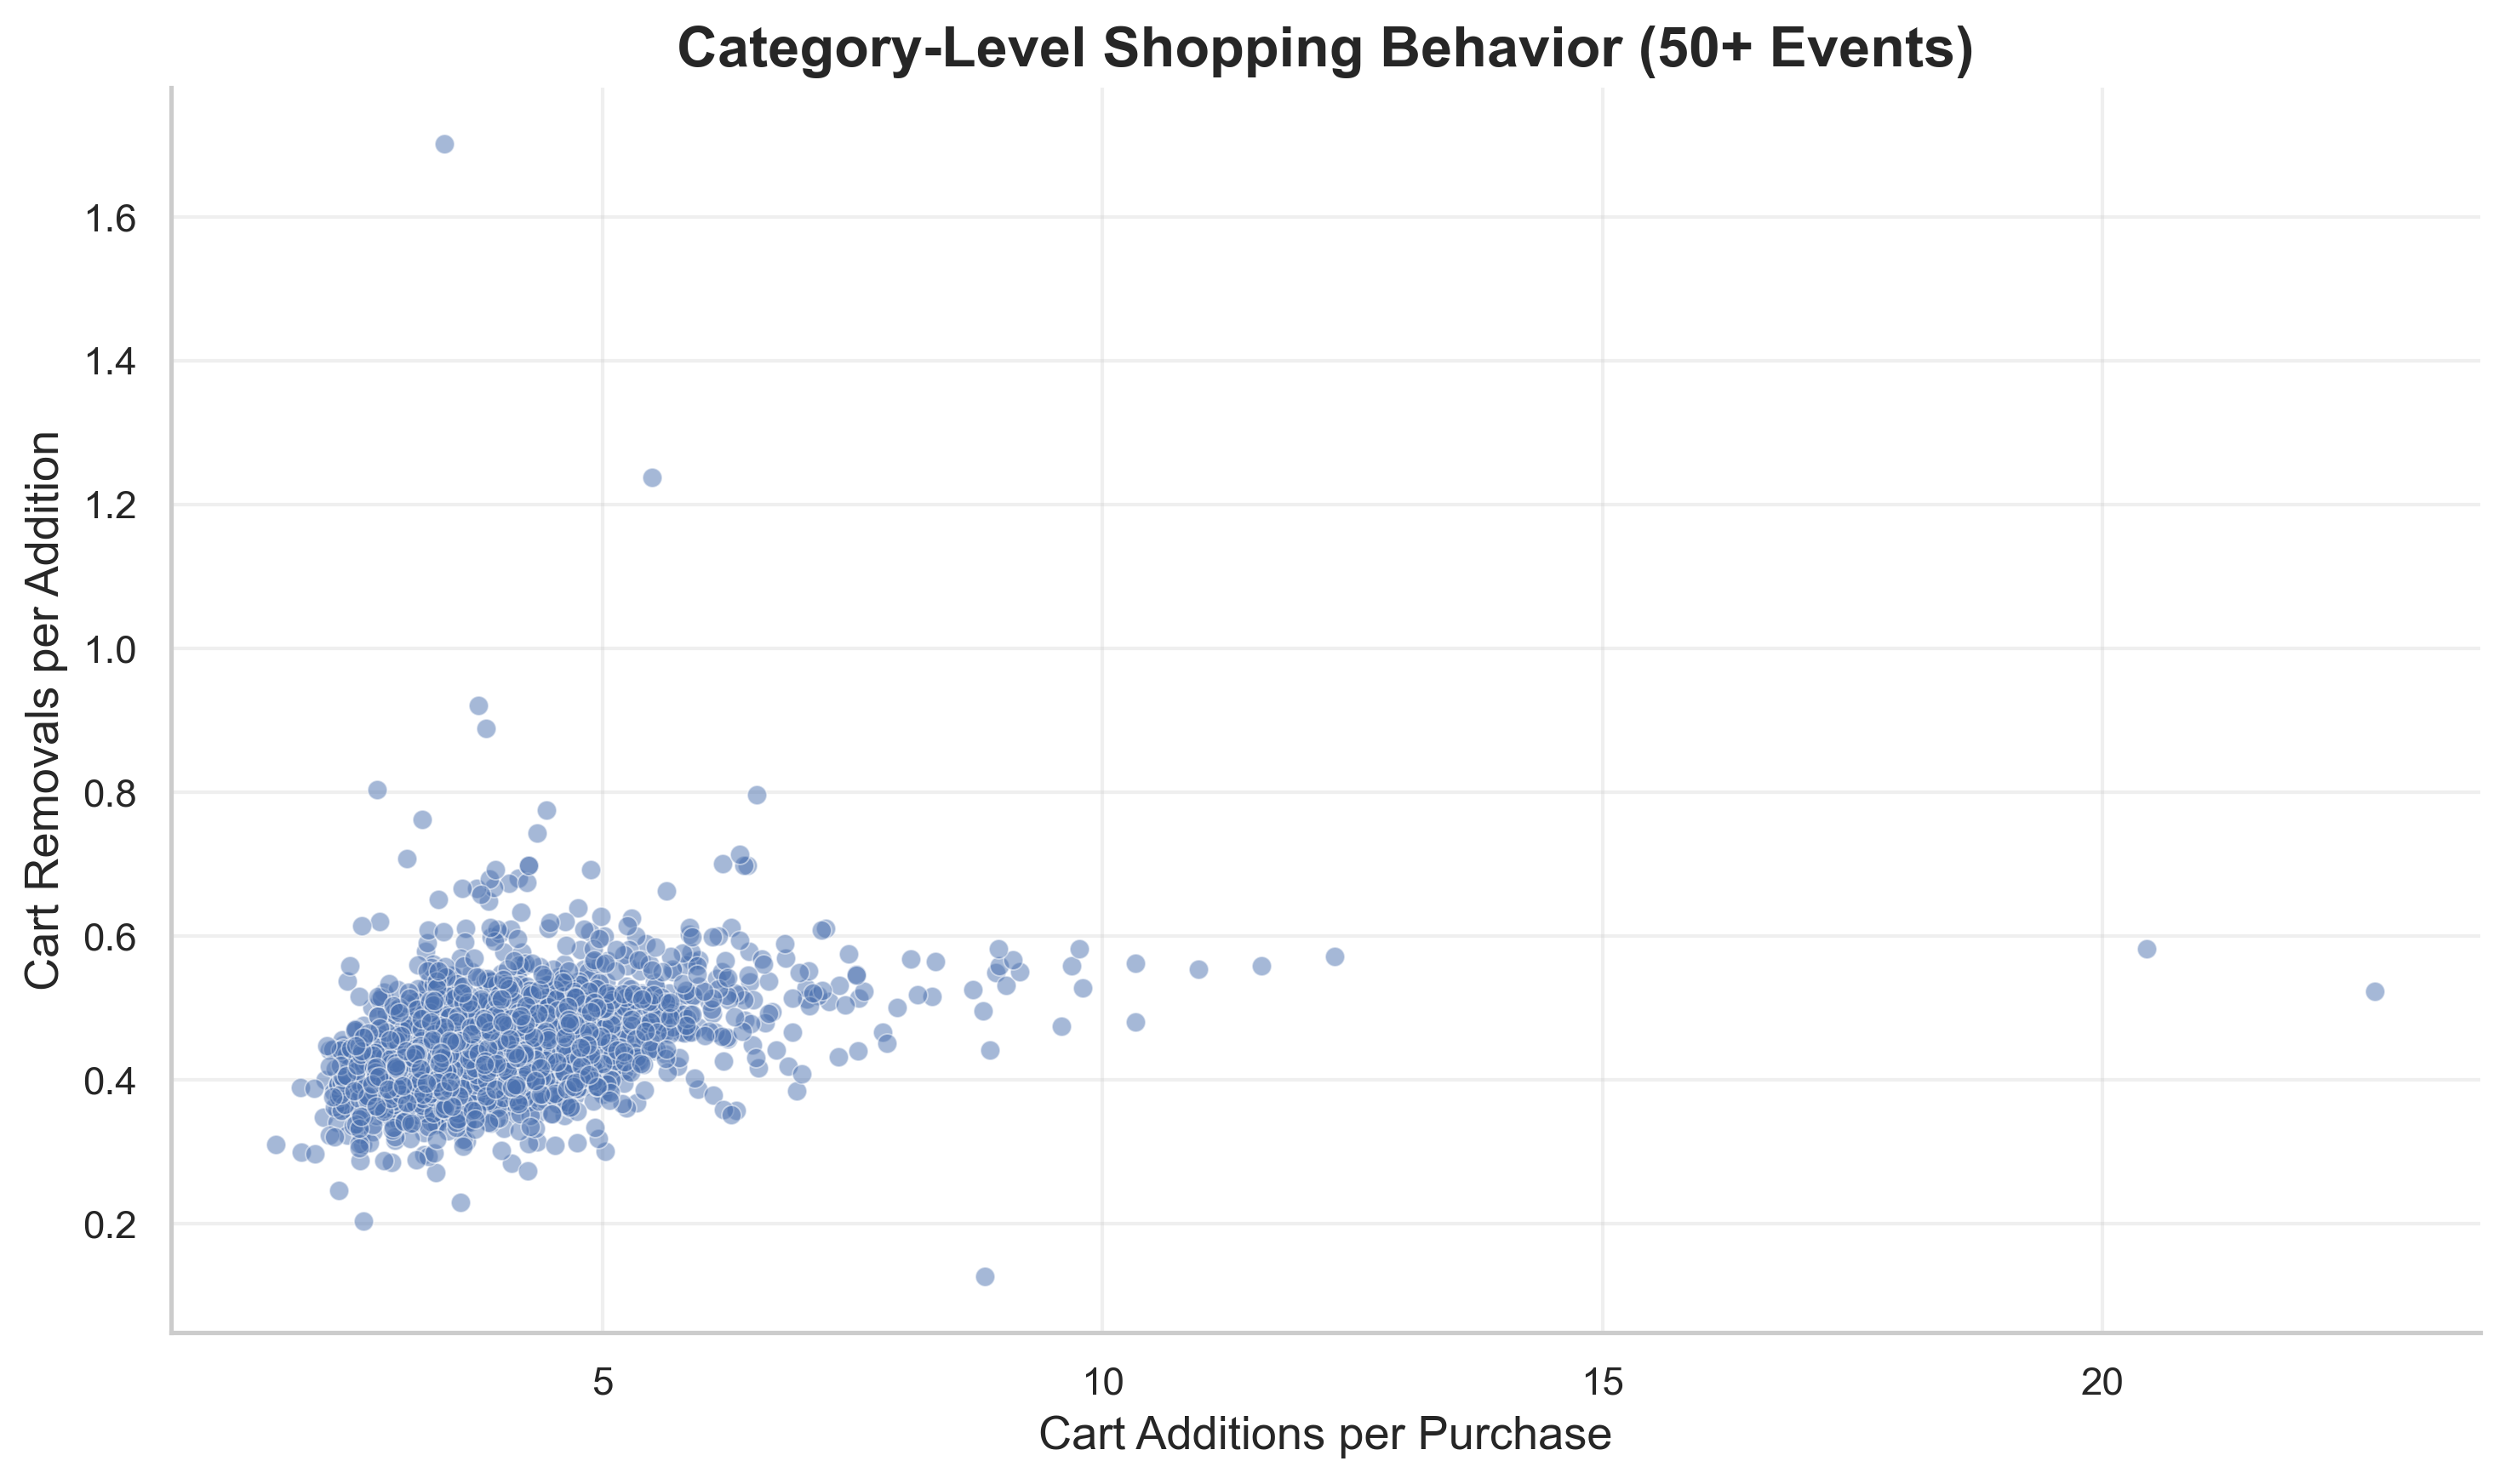

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=category_filtered,
    x="adds_per_purchase",
    y="removes_per_add",
    alpha=0.5,
    s=30
)

plt.xlabel("Cart Additions per Purchase")
plt.ylabel("Cart Removals per Addition")
plt.title("Category-Level Shopping Behavior (50+ Events)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    "figures/category_behavior_scatter.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [27]:
# Correlation between category behavioral ratios
behavior_correlation = category_filtered[
    ["adds_per_purchase", "removes_per_add"]
].corr(method="spearman")

print("Spearman correlation between behavioral ratios:")
print(behavior_correlation)

Spearman correlation between behavioral ratios:
                   adds_per_purchase  removes_per_add
adds_per_purchase           1.000000         0.402785
removes_per_add             0.402785         1.000000


In [28]:
# Categories with the highest cart additions per purchase
print("Top 10 categories by cart additions per purchase:")
display(
    category_filtered.nlargest(
        10, "adds_per_purchase"
    )[
        ["purchase_count", "cart_add_count",
         "cart_remove_count", "adds_per_purchase",
         "removes_per_add"]
    ]
)

# Categories with the highest removals per addition
print("\nTop 10 categories by cart removals per addition:")
display(
    category_filtered.nlargest(
        10, "removes_per_add"
    )[
        ["purchase_count", "cart_add_count",
         "cart_remove_count", "adds_per_purchase",
         "removes_per_add"]
    ]
)

Top 10 categories by cart additions per purchase:


,purchase_count,cart_add_count,cart_remove_count,adds_per_purchase,removes_per_add
category,,,,,
5071,133,3023,1580,22.729323,0.522660
5187,59,1206,702,20.440678,0.582090
1689,172,2119,1211,12.319767,0.571496
379,88,1020,570,11.590909,0.558824
4277,79,866,479,10.962025,0.553118
1111,610,6302,3542,10.331148,0.562044
6828,55,568,273,10.327273,0.480634
5558,203,1990,1049,9.802956,0.527136
5861,86,840,489,9.767442,0.582143



Top 10 categories by cart removals per addition:


,purchase_count,cart_add_count,cart_remove_count,adds_per_purchase,removes_per_add
category,,,,,
3806,109,372,633,3.412844,1.701613
1791,65,357,442,5.492308,1.238095
3382,70,263,242,3.757143,0.920152
6589,87,333,296,3.827586,0.888889
4454,409,1121,900,2.740831,0.802855
3719,67,438,349,6.537313,0.796804
4004,82,364,282,4.439024,0.774725
738,324,1034,788,3.191358,0.762089
2327,181,786,584,4.342541,0.743003


### Preparing Features for Clustering

We prepare category-level behavioral features for exploratory
clustering using cart additions per purchase and cart removals
per addition.

To limit the influence of extreme ratios, features are capped
at their 1st and 99th percentiles. We then standardize the
features so that differences in numerical scale do not
dominate the clustering results.

Clustering is exploratory and is intended to identify possible
behavioral groupings rather than establish that distinct
product types or recommendation strategies exist.

In [29]:
# Select behavioral features
feature_cols = ["adds_per_purchase", "removes_per_add"]

X = category_filtered[feature_cols].copy()

# Cap extreme values without removing categories
lower_bounds = X.quantile(0.01)
upper_bounds = X.quantile(0.99)

X_capped = X.clip(
    lower=lower_bounds,
    upper=upper_bounds,
    axis=1
)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_capped)

print("Original feature statistics:")
display(X.describe())

print("\nCapped feature statistics:")
display(X_capped.describe())

print("\nScaled feature means:")
print(X_scaled.mean(axis=0))

print("\nScaled feature standard deviations:")
print(X_scaled.std(axis=0))

Original feature statistics:


,adds_per_purchase,removes_per_add
count,2376.000000,2376.000000
mean,4.022299,0.450463
std,1.188886,0.071793
min,1.726190,0.126667
25%,3.318296,0.409091
50%,3.840072,0.444193
75%,4.449010,0.483907
max,22.729323,1.701613



Capped feature statistics:


,adds_per_purchase,removes_per_add
count,2376.000000,2376.000000
mean,3.999506,0.449519
std,1.014508,0.061886
min,2.368999,0.310597
25%,3.318296,0.409091
50%,3.840072,0.444193
75%,4.449010,0.483907
max,8.097328,0.665975



Scaled feature means:
[ 2.42230478e-16 -1.06910365e-16]

Scaled feature standard deviations:
[1. 1.]


### Exploratory K-Means Clustering

We apply K-means clustering to the standardized category-level
behavioral features to investigate whether categories can be
grouped according to similar shopping activity patterns.

We compare different numbers of clusters using silhouette
scores to assess cluster separation. These groupings are
exploratory and do not establish that category-specific
recommendation models will perform better.

**Clustering methodology:**

- **Features:** Cart additions per purchase and cart removals per addition, calculated using aggregate category-level event counts.
- **Activity threshold:** Categories must have at least 50 purchases and 50 cart additions. This retains 2,376 categories and approximately 96% of purchase and cart-addition events.
- **Outlier treatment:** Behavioral ratios are capped at their 1st and 99th percentiles to limit the influence of extreme observations.
- **Feature scaling:** StandardScaler is used to standardize both behavioral features before clustering.
- **Clustering:** K-means is evaluated for k = 2 through k = 8, using silhouette scores to compare cluster separation.
- **Robustness:** Cluster assignments are compared across alternative activity thresholds and with versus without percentile capping using the Adjusted Rand Index (ARI).

In [30]:
# Evaluate different numbers of clusters
k_values = range(2, 9)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"k={k}: Silhouette Score = {score:.4f}")

k=2: Silhouette Score = 0.4217
k=3: Silhouette Score = 0.3446
k=4: Silhouette Score = 0.3239
k=5: Silhouette Score = 0.3283
k=6: Silhouette Score = 0.3417
k=7: Silhouette Score = 0.3284
k=8: Silhouette Score = 0.3204


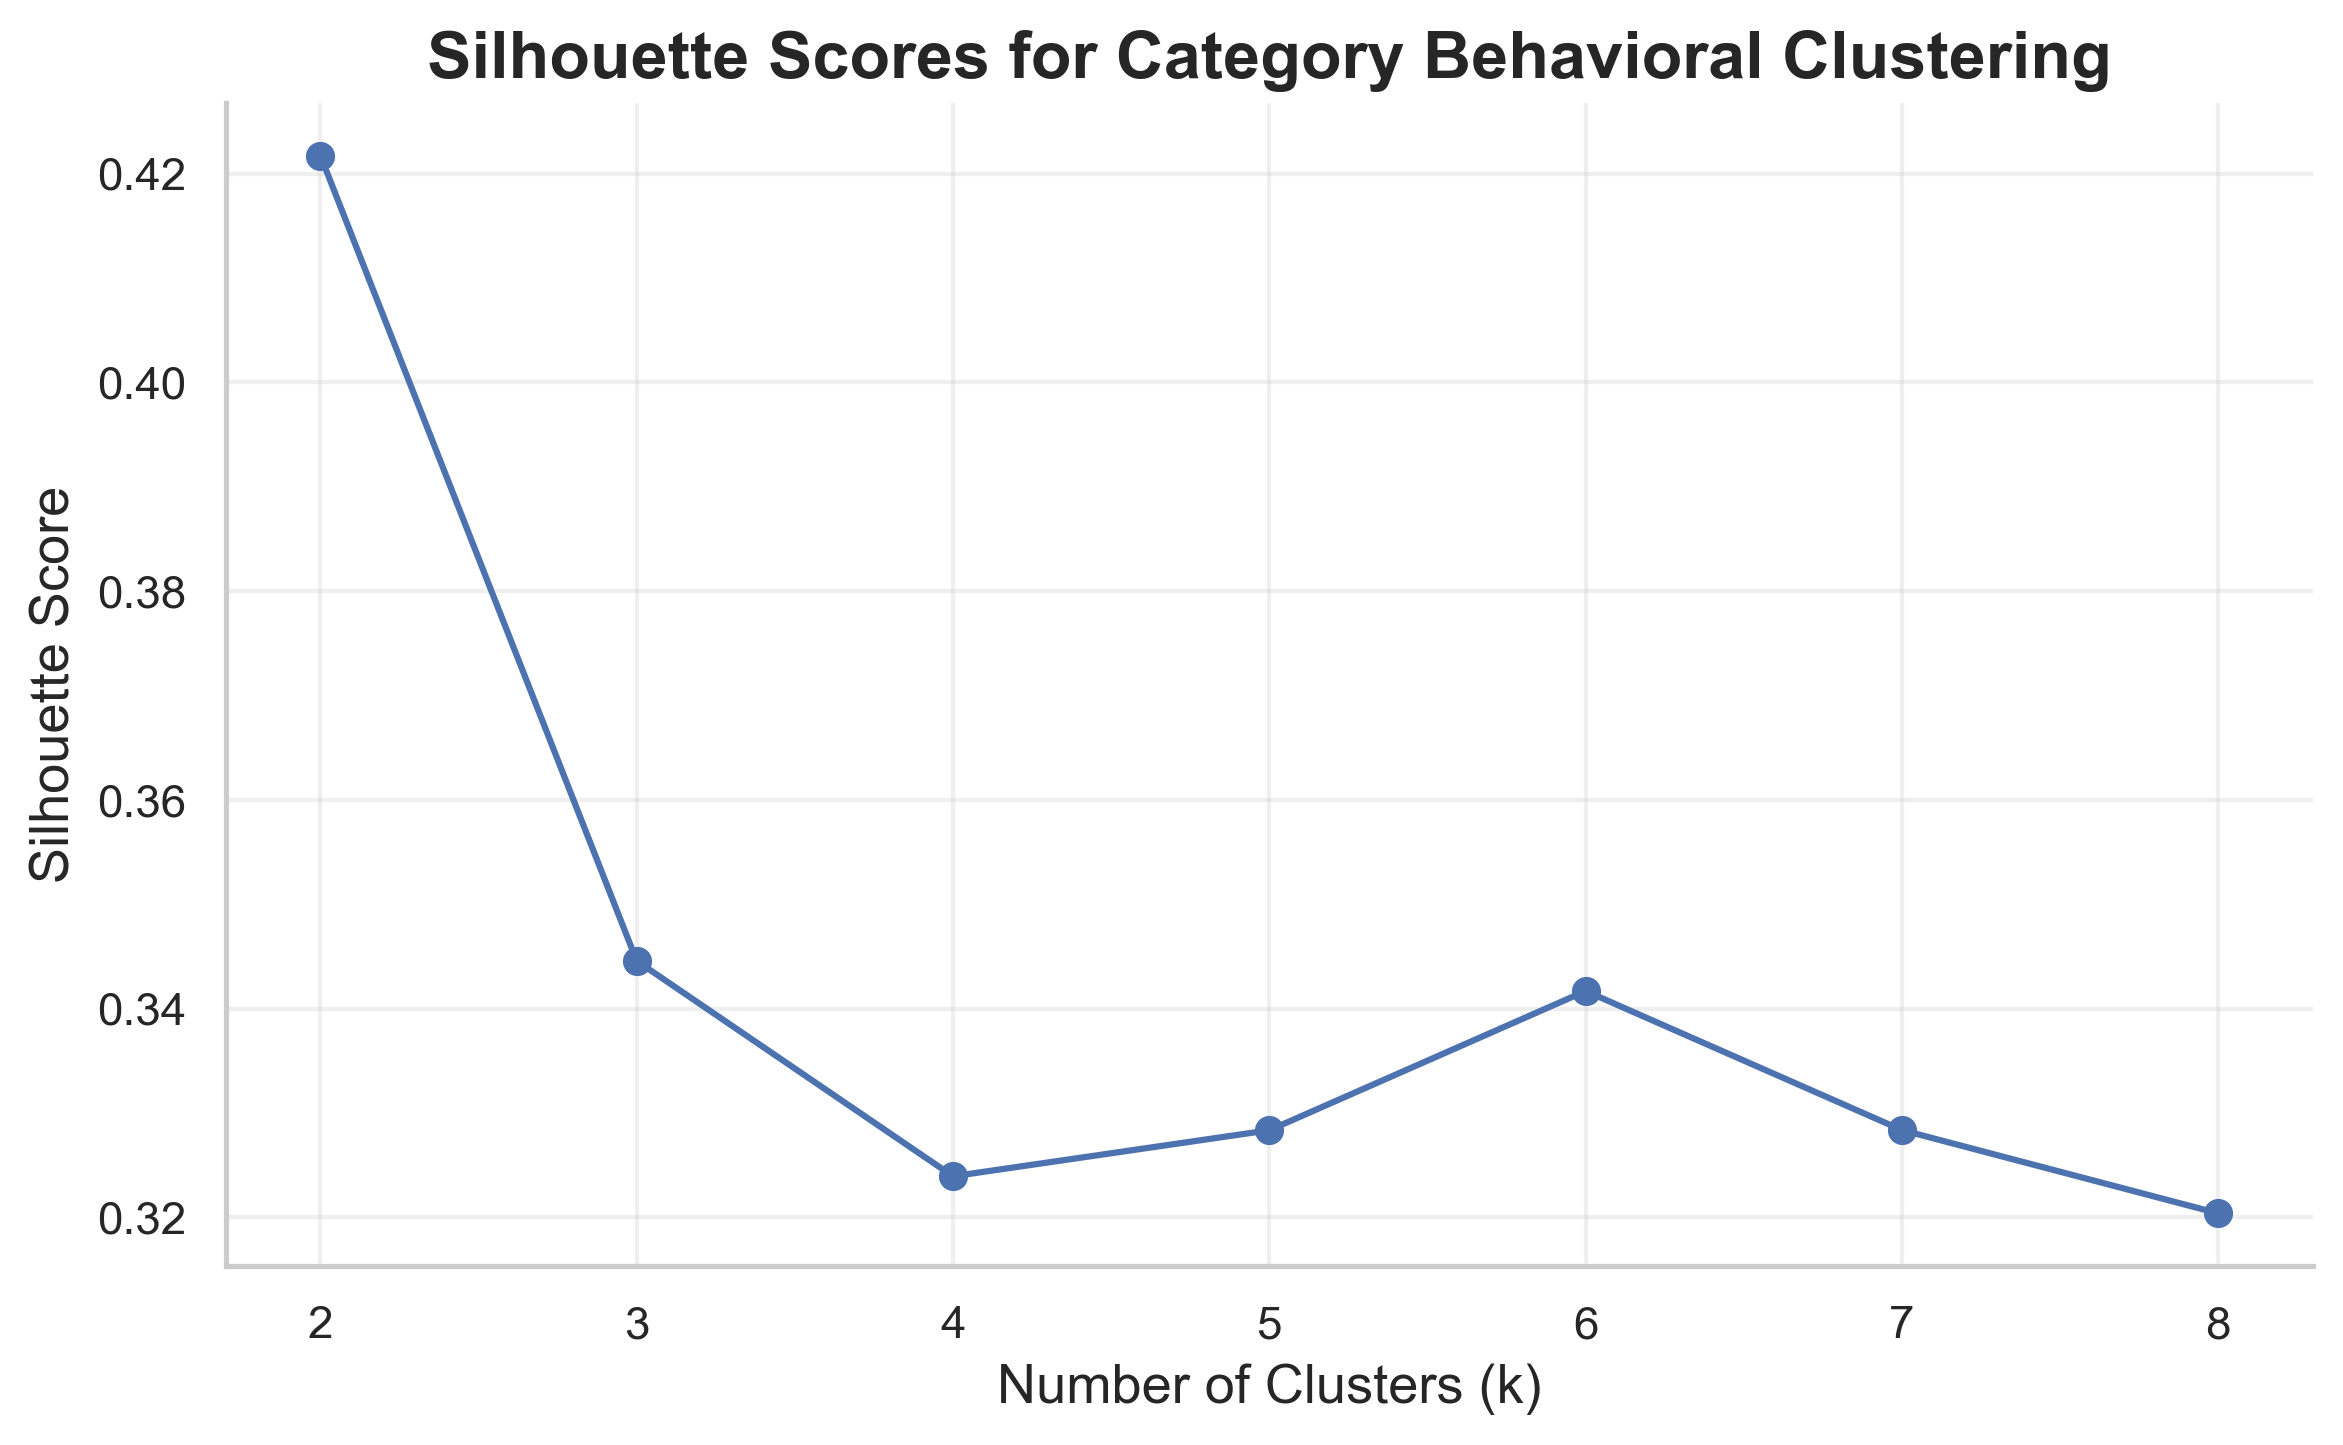

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Category Behavioral Clustering")

plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    "figures/clustering_silhouette_scores.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Two-Cluster Behavioral Analysis

Among the tested K-means configurations (k=2 through k=8),
the two-cluster solution achieved the highest silhouette
score (0.4217).

We examine the resulting cluster sizes and behavioral
characteristics to determine whether the groups represent
meaningful differences in category-level shopping activity.

In [32]:
# Fit K-means with two clusters
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Assign each category to a cluster
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to our filtered category dataset
category_clustered = category_filtered.copy()
category_clustered["cluster"] = cluster_labels

# Examine cluster sizes
print("Number of categories per cluster:")
print(category_clustered["cluster"].value_counts().sort_index())

Number of categories per cluster:
cluster
0     769
1    1607
Name: count, dtype: int64


In [33]:
# Compare average behavioral metrics across clusters
cluster_summary = category_clustered.groupby("cluster").agg(
    n_categories=("purchase_count", "size"),
    mean_adds_per_purchase=("adds_per_purchase", "mean"),
    median_adds_per_purchase=("adds_per_purchase", "median"),
    mean_removes_per_add=("removes_per_add", "mean"),
    median_removes_per_add=("removes_per_add", "median"),
    total_purchases=("purchase_count", "sum"),
    total_cart_adds=("cart_add_count", "sum")
)

display(cluster_summary.round(3))

,n_categories,mean_adds_per_purchase,median_adds_per_purchase,mean_removes_per_add,median_removes_per_add,total_purchases,total_cart_adds
cluster,,,,,,,
0,769,5.031,4.764,0.512,0.502,358796,1890839
1,1607,3.540,3.500,0.421,0.424,765711,2809676


### Visualization of Behavioral Clusters

We visualize the two-cluster K-means solution using the
behavioral features after percentile capping.

Each point represents an anonymized product category.
Colors indicate the cluster assignments based on standardized
cart additions per purchase and cart removals per addition.

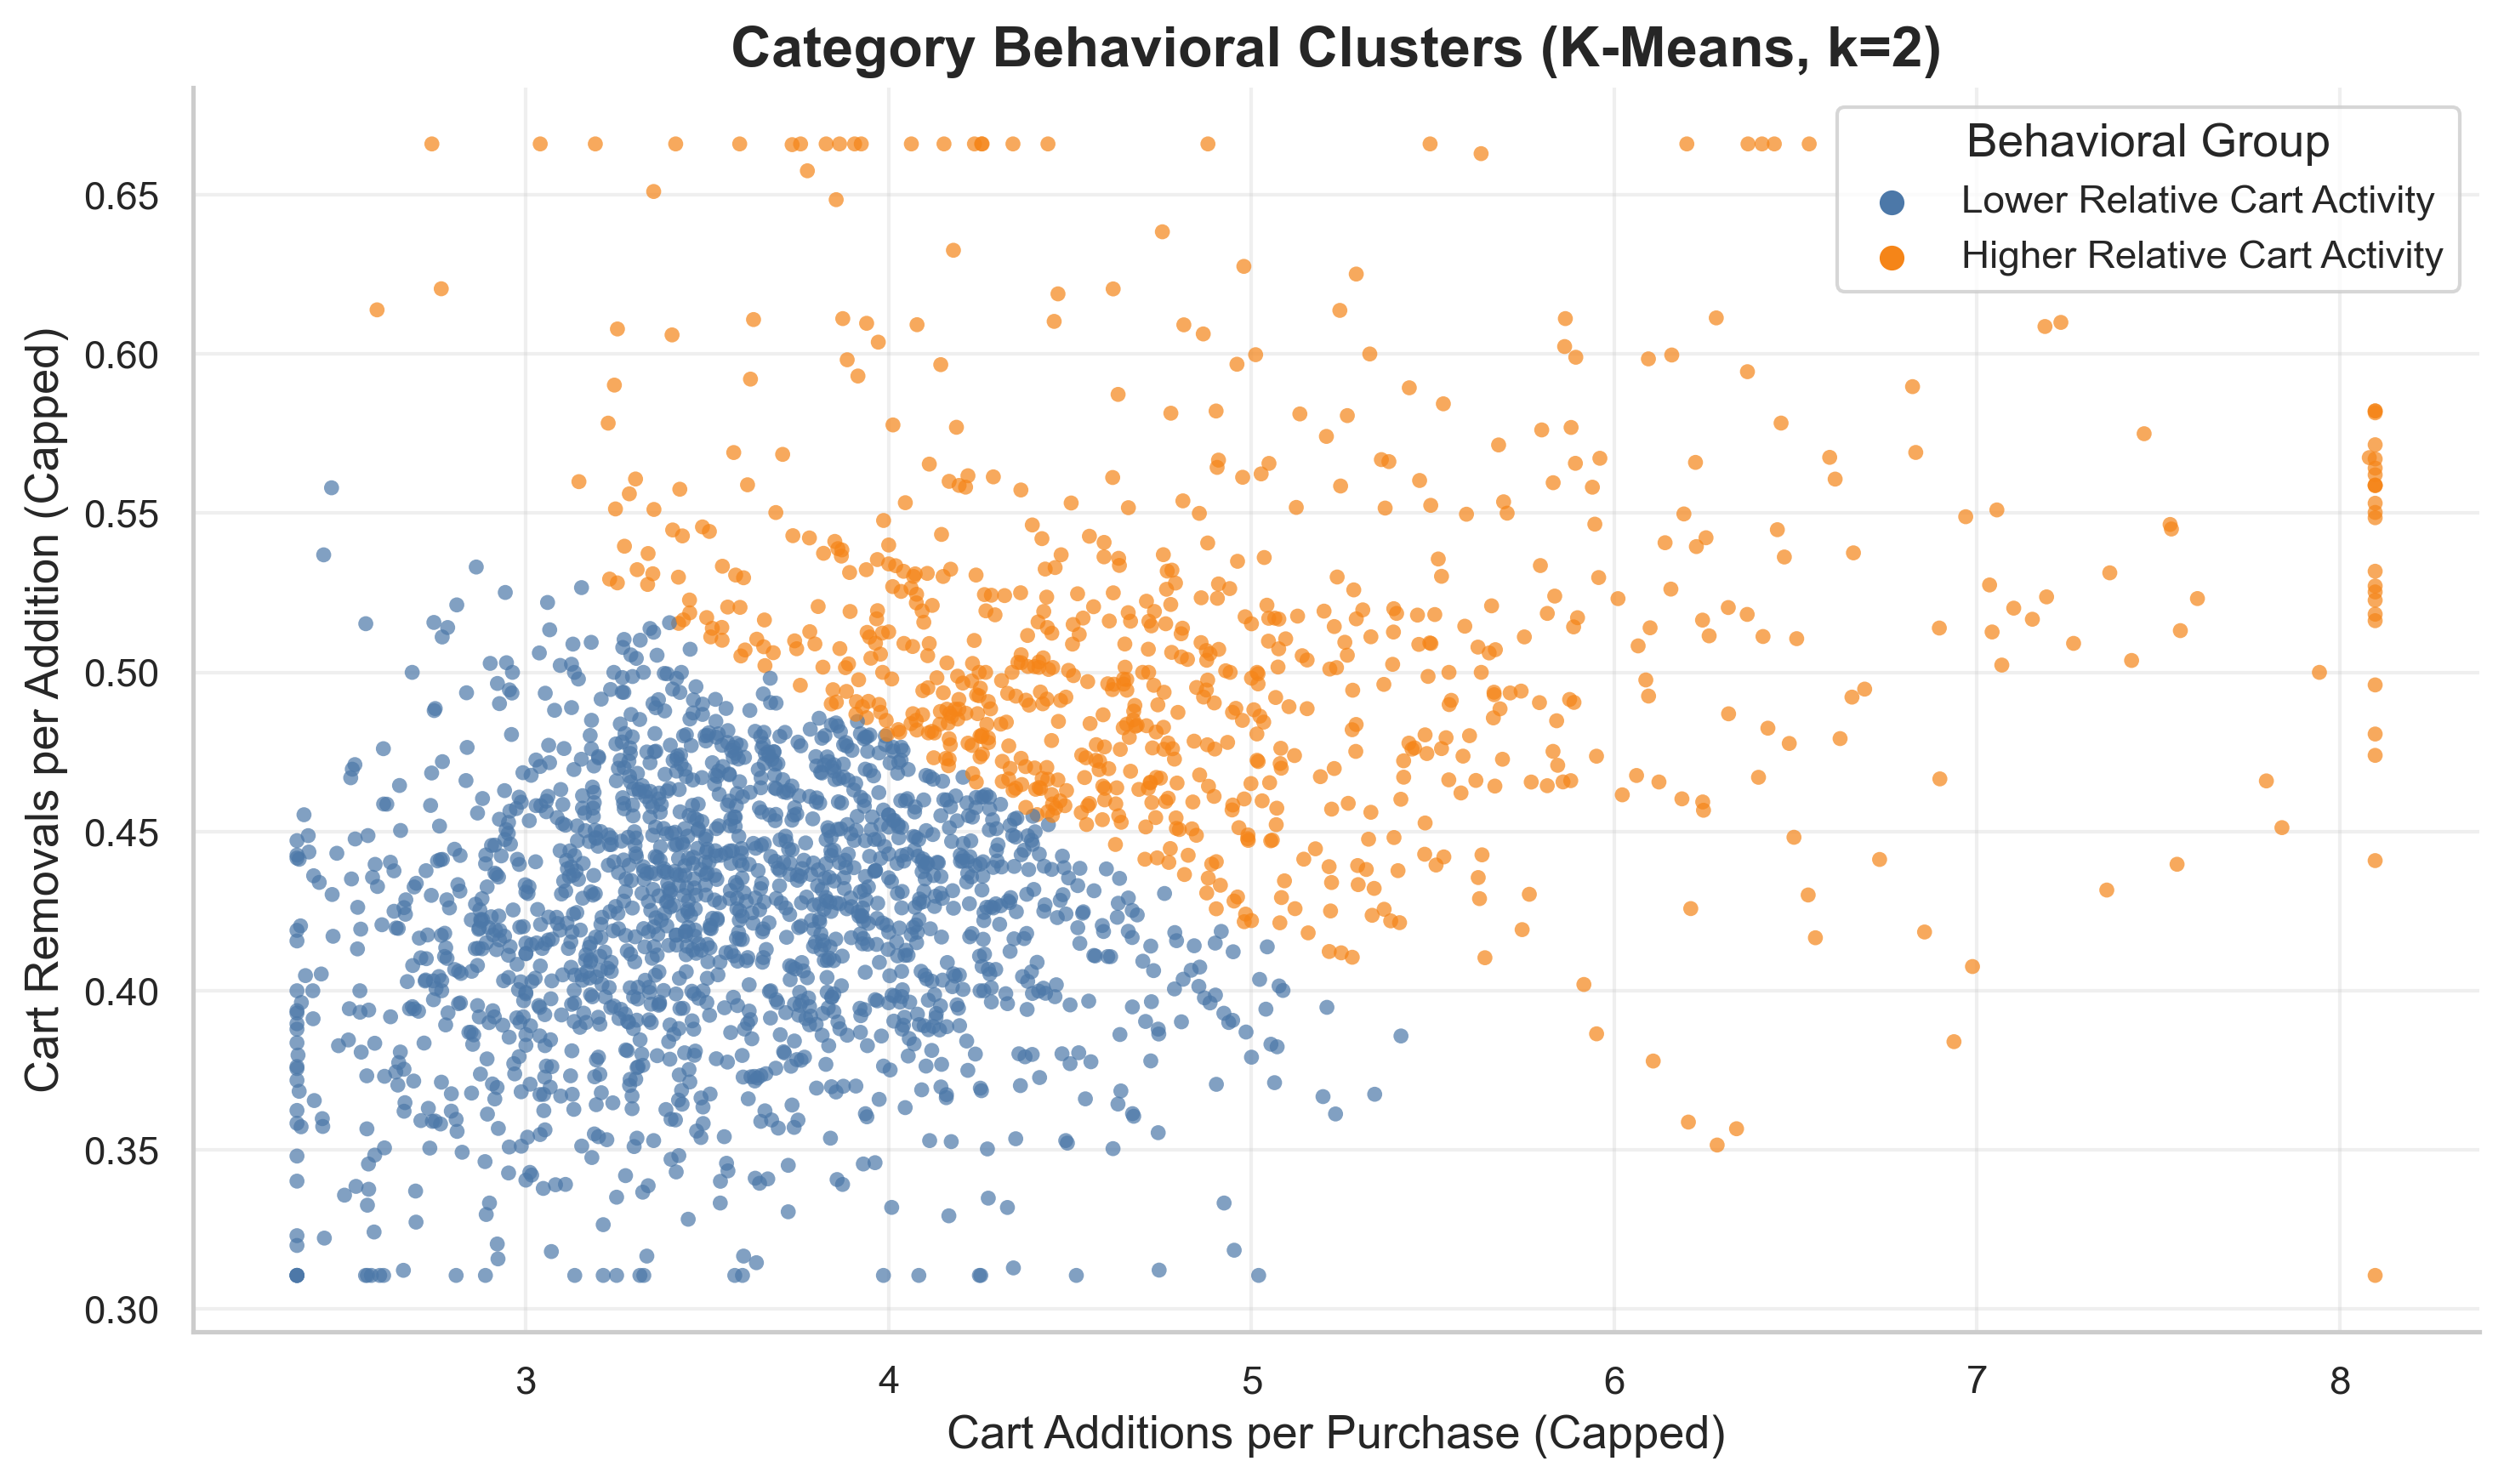

In [34]:
# Prepare capped behavioral features and cluster labels
cluster_plot = X_capped.copy()
cluster_plot["cluster"] = cluster_labels

# Add descriptive cluster labels
cluster_plot["cluster_name"] = cluster_plot["cluster"].map({
    0: "Higher Relative Cart Activity",
    1: "Lower Relative Cart Activity"
})

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cluster_plot,
    x="adds_per_purchase",
    y="removes_per_add",
    hue="cluster_name",
    hue_order=[
        "Lower Relative Cart Activity",
        "Higher Relative Cart Activity"
    ],
    palette={
    "Lower Relative Cart Activity": "#4C78A8",
    "Higher Relative Cart Activity": "#F58518"
    },
    alpha=0.7,
    s=18,
    linewidth=0
)

plt.xlabel("Cart Additions per Purchase (Capped)")
plt.ylabel("Cart Removals per Addition (Capped)")
plt.title("Category Behavioral Clusters (K-Means, k=2)")

plt.legend(title="Behavioral Group")
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig(
    "figures/category_behavior_clusters.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Clustering Robustness Check

We compare the two-cluster K-means solution with and without
percentile capping to evaluate whether the resulting category
groupings are sensitive to extreme behavioral ratios.

We use the Adjusted Rand Index (ARI) to compare cluster
assignments and silhouette scores to evaluate separation.

In [35]:
# Standardize the original, uncapped behavioral features
scaler_uncapped = StandardScaler()
X_uncapped_scaled = scaler_uncapped.fit_transform(X)

# Fit K-means without percentile capping
kmeans_uncapped = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

uncapped_labels = kmeans_uncapped.fit_predict(X_uncapped_scaled)

# Compare clustering assignments
ari = adjusted_rand_score(cluster_labels, uncapped_labels)

# Compare silhouette scores
silhouette_capped = silhouette_score(X_scaled, cluster_labels)
silhouette_uncapped = silhouette_score(
    X_uncapped_scaled,
    uncapped_labels
)

print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette score (capped): {silhouette_capped:.4f}")
print(f"Silhouette score (uncapped): {silhouette_uncapped:.4f}")

print("\nCluster sizes without capping:")
print(pd.Series(uncapped_labels).value_counts().sort_index())

Adjusted Rand Index: 0.7626
Silhouette score (capped): 0.4217
Silhouette score (uncapped): 0.4474

Cluster sizes without capping:
0    1753
1     623
Name: count, dtype: int64


### Sensitivity to Minimum Activity Thresholds

We repeat the two-cluster K-means analysis using minimum
activity thresholds of 30, 50, and 100 purchase and
cart-addition events per category.

We compare cluster assignments for categories included in
both the alternative threshold and the original 50-event
analysis to evaluate whether the observed behavioral
groupings depend strongly on the filtering threshold.

In [36]:
# Compare clustering results across activity thresholds
for threshold in [30, 50, 100]:

    # Filter categories
    subset = category_summary[
        (category_summary["purchase_count"] >= threshold) &
        (category_summary["cart_add_count"] >= threshold)
    ].copy()

    # Select behavioral features
    X_subset = subset[feature_cols].copy()

    # Apply percentile capping
    X_subset = X_subset.clip(
        lower=X_subset.quantile(0.01),
        upper=X_subset.quantile(0.99),
        axis=1
    )

    # Standardize features
    X_subset_scaled = StandardScaler().fit_transform(X_subset)

    # Fit K-means
    model = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_subset_scaled)

    # Store labels indexed by category
    subset_labels = pd.Series(labels, index=subset.index)

    # Compare only categories shared with the 50-event model
    shared_categories = subset.index.intersection(
        category_clustered.index
    )

    original_labels = category_clustered.loc[
        shared_categories, "cluster"
    ]

    new_labels = subset_labels.loc[shared_categories]

    ari = adjusted_rand_score(
        original_labels,
        new_labels
    )

    print(f"\nThreshold: {threshold}")
    print(f"Categories retained: {len(subset):,}")
    print(f"Shared categories: {len(shared_categories):,}")
    print(f"ARI vs. 50-event model: {ari:.4f}")


Threshold: 30
Categories retained: 2,901
Shared categories: 2,376
ARI vs. 50-event model: 0.9678

Threshold: 50
Categories retained: 2,376
Shared categories: 2,376
ARI vs. 50-event model: 1.0000

Threshold: 100
Categories retained: 1,679
Shared categories: 1,679
ARI vs. 50-event model: 0.9310


### Key Findings

Category-level behavioral analysis revealed variation in cart activity relative to purchasing activity. Across categories with at least 50 purchases and 50 cart additions, the median was **3.84 cart additions per purchase** and **0.444 cart removals per addition**. The two behavioral ratios exhibited a moderate positive association (Spearman correlation = 0.403), indicating that categories with relatively more cart additions per purchase also tended to have higher removal-to-addition ratios.

Exploratory K-means clustering was performed on 2,376 categories using standardized behavioral ratios after capping extreme values at the 1st and 99th percentiles. Among the tested configurations (k = 2–8), **k = 2 achieved the highest silhouette score (0.4217)**. The resulting groups differed in their average behavioral characteristics. Cluster 0 (769 categories) had higher mean cart additions per purchase (5.03) and removals per addition (0.512), while Cluster 1 (1,607 categories) exhibited lower ratios (3.54 and 0.421, respectively).

Sensitivity analyses showed that cluster assignments were highly consistent across minimum-activity thresholds of 30 and 100 events, with Adjusted Rand Index scores of **0.968 and 0.931**, respectively, relative to the 50-event baseline. Removing percentile capping resulted in an ARI of 0.763, indicating somewhat greater sensitivity to extreme observations.

Overall, the findings suggest that anonymized product categories exhibit measurable differences in aggregate shopping behavior. Although K-means identified two relatively stable behavioral groupings, the visualizations indicate a largely continuous distribution rather than clearly separated natural clusters. These results motivate further investigation of category-conditioned recommendation models but do not establish that category-specific modeling will improve next-purchase prediction.

**Limitations:** The behavioral ratios represent aggregate event frequencies rather than customer-level conversion probabilities. Results are restricted to the active-user cohort, and the clustering analysis emphasizes categories with sufficient observed activity. The anonymized category identifiers also limit interpretation of the underlying product types.

## 4. Overall Conclusions and Implications

This exploratory analysis identified several characteristics of the Synerise RecSys 2025 dataset that are relevant to the development of behavior-aware recommendation models.

**Item popularity:** Purchase activity exhibits a strong long-tail distribution. Approximately 66% of purchased products appear in only one purchase event, while the top 10% of purchased products account for 52.08% of purchases. This supports evaluating a popularity-based baseline and highlights challenges associated with sparse item purchase histories.

**Category distribution:** Products and shopping interactions are unevenly distributed across anonymized categories. Category size is strongly associated with purchase activity (Spearman correlation = 0.947), but purchase frequency relative to catalog size differs across categories. Cart additions also cover more categories than purchases, suggesting that cart events provide behavioral observations across a broader portion of the product catalog.

**Category behavioral differences:** Categories exhibit variation in their aggregate cart interaction ratios. Exploratory K-means clustering identified two groups characterized by higher and lower relative cart activity. The two-cluster solution achieved the highest silhouette score among the tested configurations (0.4217), and assignments were relatively stable across different activity thresholds and outlier treatments. However, the groups are not clearly separated, indicating that category behavior may vary continuously rather than forming distinct natural clusters.

### Implications for Recommendation Modeling

These findings motivate evaluating whether incorporating cart interactions and category information improves next-purchase recommendations. In particular, the observed behavioral differences provide a basis for investigating category-conditioned models alongside global recommendation models.

However, the EDA does not establish that cart activity improves next-purchase prediction or that category-conditioned models outperform global approaches. These questions must be answered through controlled modeling experiments using consistent temporal data splits and ranking metrics.

### Limitations

- **Active-user selection:** The analysis focuses on users with at least five recorded purchase or cart events, so results may not generalize to less active customers.
- **Anonymized categories:** Category IDs cannot be reliably mapped to human-readable product types, limiting interpretation of the observed behavioral groupings.
- **Aggregate event ratios:** Cart additions per purchase and removals per addition are event-frequency measures, not customer-level conversion probabilities.
- **Exploratory clustering:** K-means partitions categories based on selected behavioral features and does not establish naturally distinct category types.
- **Temporal information:** Category-level statistics were calculated using the full observation period. Any category features or clusters used in predictive modeling must be constructed using training-period data only to avoid future-information leakage.